# SVM Model for Solar Panel Image Classification

## Summary
This notebook implements an SVM (Support Vector Machine) classifier for solar panel image classification. The model processes image data through a preprocessing pipeline including standardization and PCA dimensionality reduction, then trains an SVM with RBF kernel for classification into 6 categories of solar panel conditions.

In [1]:
import pandas as pd
import os
from skimage.transform import resize
from skimage.io import imread
import numpy as np
from sklearn import svm
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
import kagglehub
import matplotlib.pyplot as plt

['Snow-Covered', 'Clean', 'Physical-Damage', 'Bird-drop', 'Electrical-damage', 'Dusty']
Class Distribution:
----------------------------------------
Bird-drop: 1503 images
Clean: 503 images
Dusty: 1371 images
Electrical-damage: 756 images
Physical-Damage: 535 images
Snow-Covered: 970 images


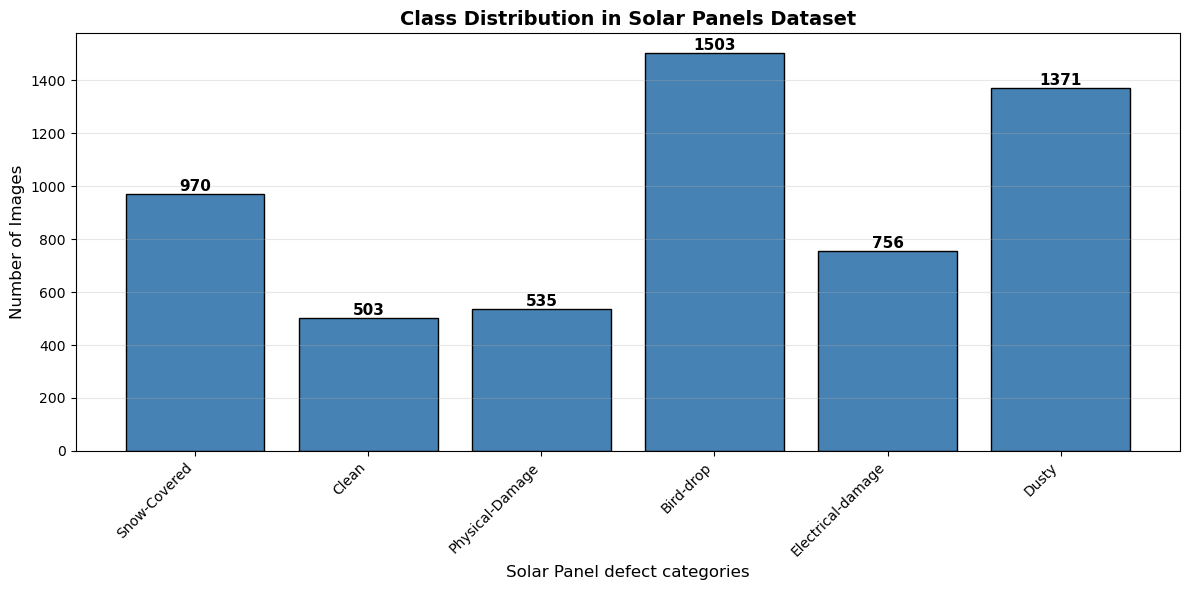

In [2]:
# construct classes array
path = kagglehub.dataset_download("ossossh/solar-pannels-image-enhanced")

classes_path = os.path.join(path, 'Data4T2')
classes = [d for d in os.listdir(classes_path) if os.path.isdir(os.path.join(classes_path, d))]

print(classes)

# Count images in each class
class_counts = {}
for class_name in classes:
    class_dir = os.path.join(classes_path, class_name)
    image_count = len([f for f in os.listdir(class_dir) if f.lower().endswith(('.png', '.jpg', '.jpeg'))])
    class_counts[class_name] = image_count

# Display class distribution
print("Class Distribution:")
print("-" * 40)
for class_name, count in sorted(class_counts.items()):
    print(f"{class_name}: {count} images")

# Visualize with bar chart
plt.figure(figsize=(12, 6))
bars = plt.bar(class_counts.keys(), class_counts.values(), color='steelblue', edgecolor='black')
plt.xlabel('Solar Panel defect categories', fontsize=12)
plt.ylabel('Number of Images', fontsize=12)
plt.title('Class Distribution in Solar Panels Dataset', fontsize=14, fontweight='bold')
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', alpha=0.3)

# Add value labels on top of each bar
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height,
            f'{int(height)}',
            ha='center', va='bottom', fontsize=11, fontweight='bold')

plt.tight_layout()
plt.show()

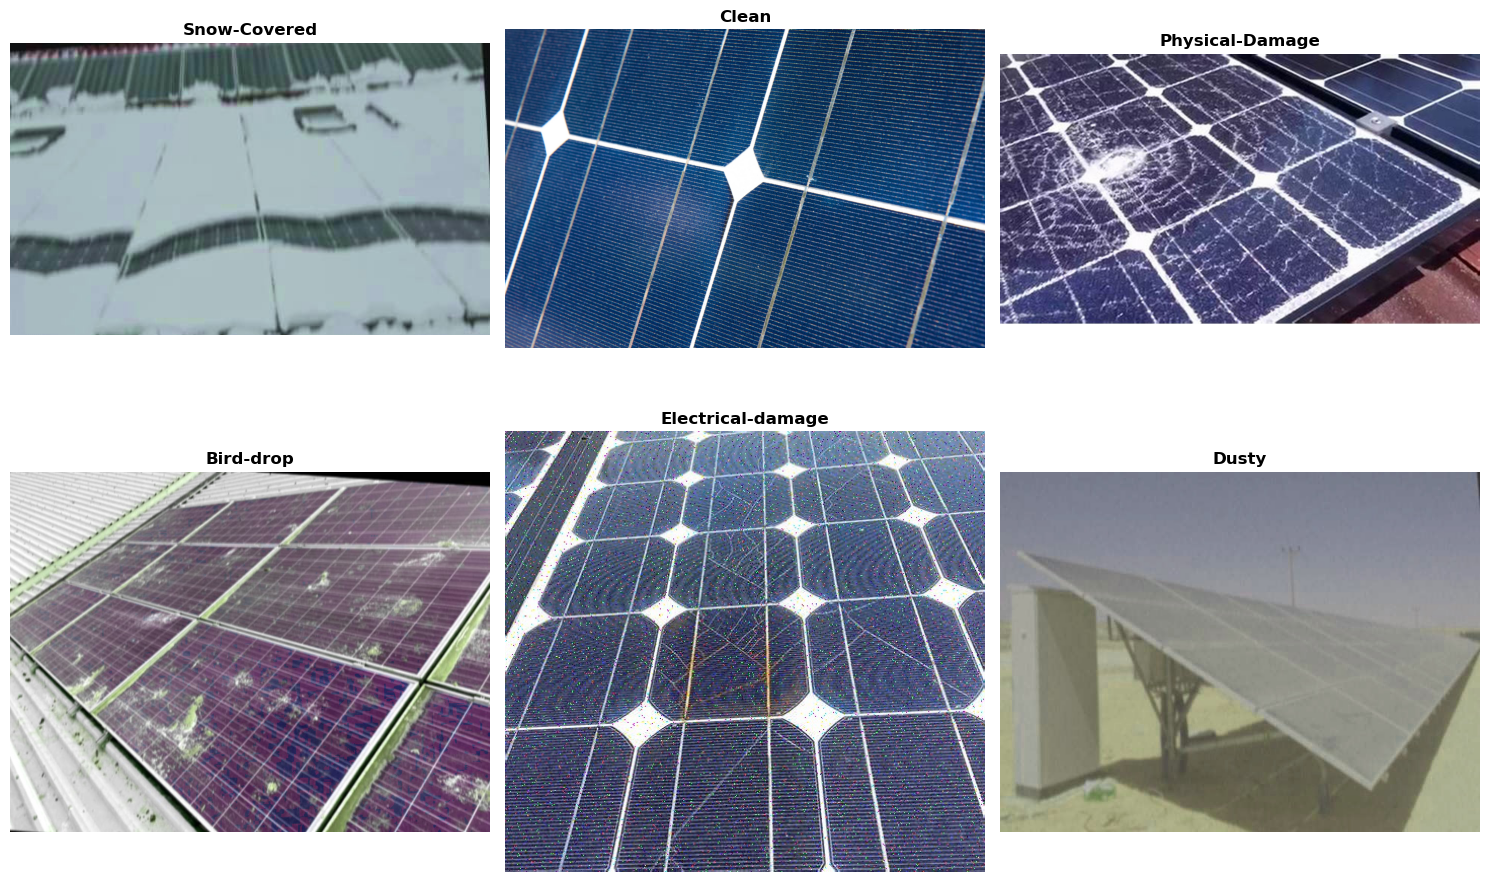

In [16]:
# Load and display sample images from each class
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.flatten()

for idx, class_name in enumerate(classes):
    class_dir = os.path.join(classes_path, class_name)
    images = [f for f in os.listdir(class_dir) if f.lower().endswith(('.png', '.jpg', '.jpeg'))]
    
    # Load first image from each class
    if images:
        img_path = os.path.join(class_dir, images[np.random.randint(0, len(images)-1)])
        img = imread(img_path)
        axes[idx].imshow(img)
        axes[idx].set_title(f'{class_name}', fontweight='bold')
        axes[idx].axis('off')

plt.tight_layout()
plt.show()

In [17]:
# load images in parallel
from concurrent.futures import ThreadPoolExecutor
import warnings
warnings.filterwarnings('ignore')

flat_data_arr=[]
target_arr=[]

# Define valid image extensions
valid_extensions = ('.jpg', '.jpeg', '.png', '.bmp', '.tiff', '.tif', '.JPG', '.JPEG', '.PNG', '.BMP', '.TIFF', '.TIF')

def load_single_image(img_path, category_index):
    """Load and process a single image"""
    try:
        img_array = imread(img_path)
        img_resized = resize(img_array, (150, 150, 3))
        return img_resized.flatten(), category_index
    except Exception as e:
        print(f"Error loading {img_path}: {e}")
        return None, None

for category in classes:
    print(f'loading... category : {category}')
    class_path = os.path.join(classes_path, category)
    category_index = classes.index(category)
    
    # Collect all image paths for this category
    image_paths = []
    for root, dirs, files in os.walk(class_path):
        for img in files:
            if img.lower().endswith(valid_extensions):
                img_full_path = os.path.join(root, img)
                image_paths.append(img_full_path)
    
    # Load images in parallel using ThreadPoolExecutor
    with ThreadPoolExecutor(max_workers=6) as executor:
        results = executor.map(lambda path: load_single_image(path, category_index), image_paths)
        
        for img_data, cat_index in results:
            if img_data is not None:
                flat_data_arr.append(img_data)
                target_arr.append(cat_index)
    
    print(f'loaded category:{category} successfully')

flat_data = np.array(flat_data_arr)
target = np.array(target_arr)
print(f'Total images loaded: {len(flat_data_arr)}')

loading... category : Snow-Covered
loaded category:Snow-Covered successfully
loading... category : Clean
loaded category:Clean successfully
loading... category : Physical-Damage
loaded category:Physical-Damage successfully
loading... category : Bird-drop
loaded category:Bird-drop successfully
loading... category : Electrical-damage
loaded category:Electrical-damage successfully
loading... category : Dusty
loaded category:Dusty successfully
Total images loaded: 5638


In [18]:
#dataframe
df=pd.DataFrame(flat_data) 
df['Target']=target
df.shape

(5638, 67501)

In [19]:
#input data 
x=df.iloc[:,:-1] 
#output data
y=df.iloc[:,-1]

In [20]:
# Splitting the data into training and testing sets
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.20,
                                               random_state=77,
                                               stratify=y)

In [21]:
# Solution: Reduce dimensionality with PCA before SVM with fixed parameters
from sklearn.decomposition import PCA
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
import time

params = {
    'C': 100,
    'gamma': 'scale',
    'kernel': 'rbf'
}

# Create a pipeline with scaling, PCA, and SVM using fixed params
# Added probability=True to SVC to enable predict_proba()
pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('pca', PCA(n_components=340)),  # Reduce to 340 components
    ('svm', svm.SVC(probability=True, random_state=42, **params))
])

print("Training SVM with PCA using fixed parameters...")
print(f"Using parameters: {params}")
start_time = time.time()

# Train the model
pipeline.fit(x_train, y_train)

end_time = time.time()
training_time = end_time - start_time

print(f"Training completed in {training_time:.2f} seconds")

# Make predictions
y_pred_pca = pipeline.predict(x_test)
# Calculate accuracy
accuracy_pca = accuracy_score(y_test, y_pred_pca)
print(f"Test accuracy with PCA+SVM: {accuracy_pca:.4f}")

Training SVM with PCA using fixed parameters...
Using parameters: {'C': 100, 'gamma': 'scale', 'kernel': 'rbf'}
Training completed in 60.11 seconds
Test accuracy with PCA+SVM: 0.8520


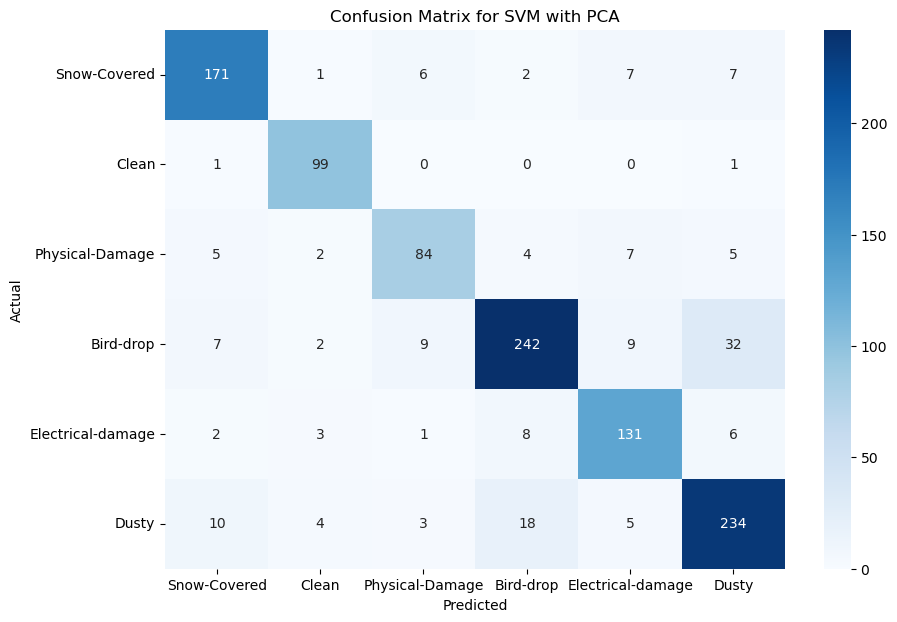

In [ ]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# Show confusion matrix
cm = confusion_matrix(y_test, y_pred_pca)

# Plot confusion matrix
plt.figure(figsize=(10, 7))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=classes, yticklabels=classes)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix for SVM with PCA')
plt.show()

In [23]:
# Print classification report for additional metrics
from sklearn.metrics import classification_report
print(classification_report(y_test, y_pred_pca, target_names=classes))

                   precision    recall  f1-score   support

     Snow-Covered       0.87      0.88      0.88       194
            Clean       0.89      0.98      0.93       101
  Physical-Damage       0.82      0.79      0.80       107
        Bird-drop       0.88      0.80      0.84       301
Electrical-damage       0.82      0.87      0.85       151
            Dusty       0.82      0.85      0.84       274

         accuracy                           0.85      1128
        macro avg       0.85      0.86      0.86      1128
     weighted avg       0.85      0.85      0.85      1128



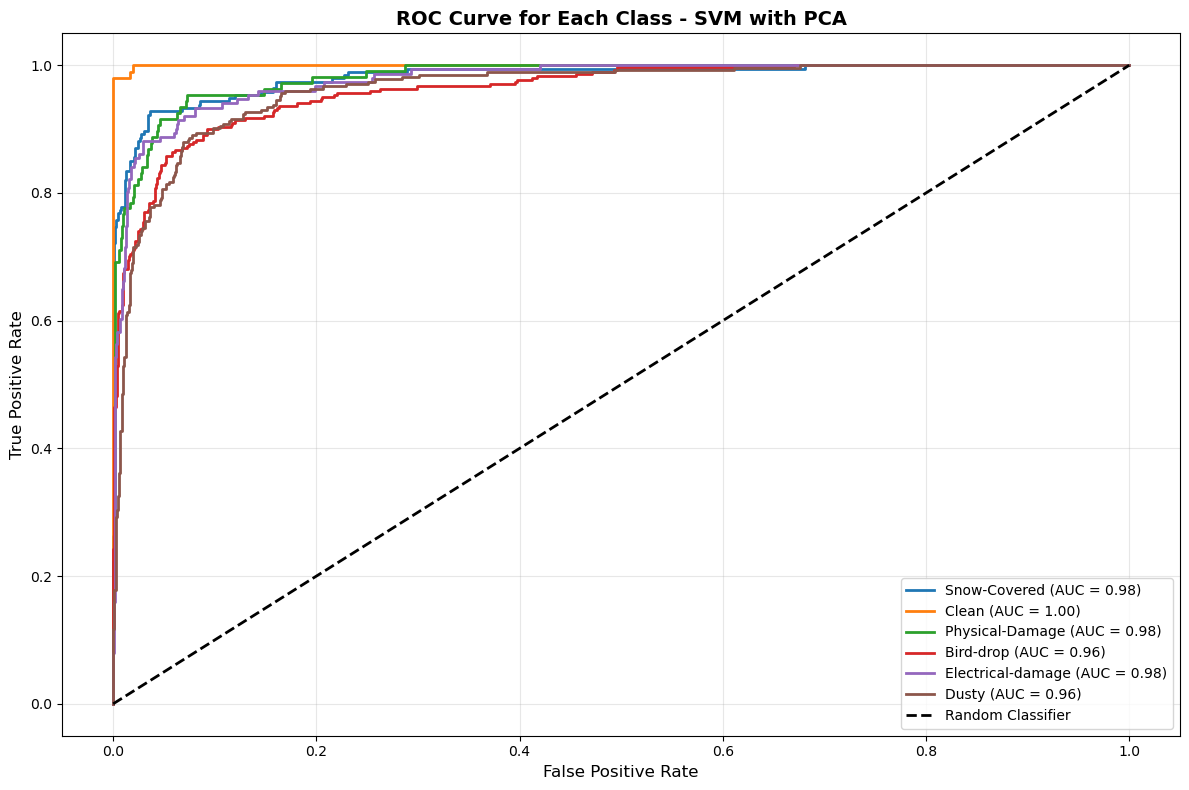

In [26]:
# ROC Curve (Receiver Operating Characteristic)
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize

# Get probabilities for each class
y_proba = pipeline.predict_proba(x_test)

# Binarize the output for multiclass ROC
y_test_bin = label_binarize(y_test, classes=range(len(classes)))

# Calculate ROC curve and AUC for each class
fpr = dict()
tpr = dict()
roc_auc = dict()

for i in range(len(classes)):
    fpr[i], tpr[i], _ = roc_curve(y_test_bin[:, i], y_proba[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

# Plot ROC curves for all classes
plt.figure(figsize=(12, 8))
for i in range(len(classes)):
    plt.plot(fpr[i], tpr[i], 
             label=f'{classes[i]} (AUC = {roc_auc[i]:.2f})',
             linewidth=2)

plt.plot([0, 1], [0, 1], 'k--', linewidth=2, label='Random Classifier')
plt.xlabel('False Positive Rate', fontsize=12)
plt.ylabel('True Positive Rate', fontsize=12)
plt.title('ROC Curve for Each Class - SVM with PCA', fontsize=14, fontweight='bold')
plt.legend(loc='lower right', fontsize=10)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

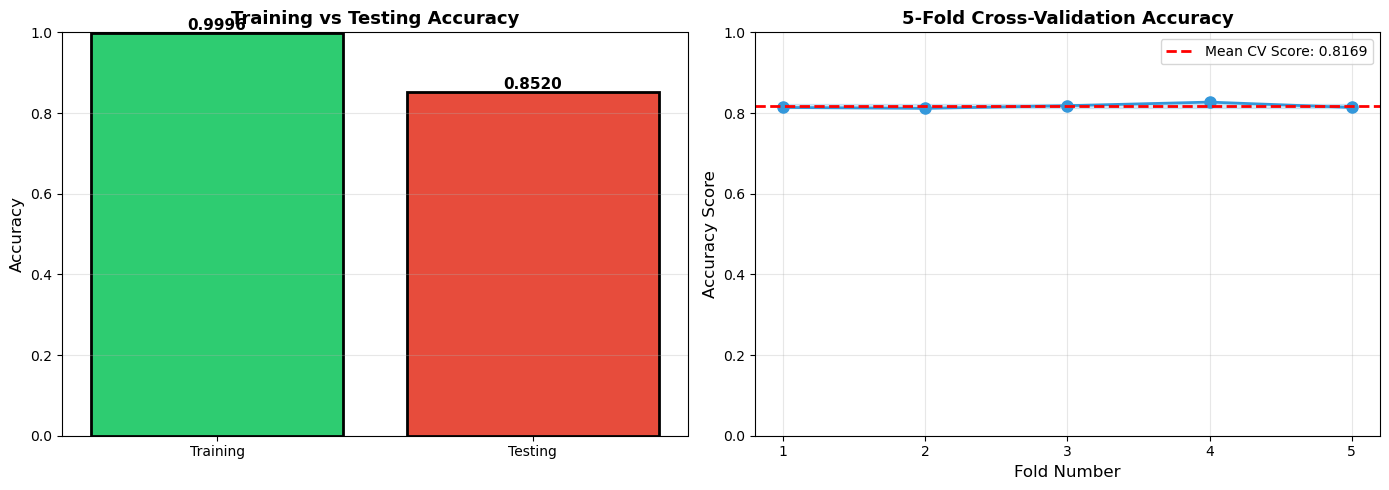

Training Accuracy: 0.9996
Testing Accuracy: 0.8520
Cross-Validation Scores: [0.81374723 0.81152993 0.81818182 0.827051   0.81374723]
Mean CV Accuracy: 0.8169 (+/- 0.0055)


In [27]:
# Training and Testing Accuracy Comparison
from sklearn.model_selection import cross_val_score

# Get training accuracy
y_train_pred = pipeline.predict(x_train)
train_accuracy = accuracy_score(y_train, y_train_pred)

# Get testing accuracy (already calculated)
test_accuracy = accuracy_score(y_test, y_pred_pca)

# Get cross-validation scores
cv_scores = cross_val_score(pipeline, x_train, y_train, cv=5, scoring='accuracy')

# Plot accuracy comparison
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Train vs Test Accuracy
accuracies = [train_accuracy, test_accuracy]
labels = ['Training', 'Testing']
colors_acc = ['#2ecc71', '#e74c3c']

bars = ax1.bar(labels, accuracies, color=colors_acc, edgecolor='black', linewidth=2)
ax1.set_ylabel('Accuracy', fontsize=12)
ax1.set_title('Training vs Testing Accuracy', fontsize=13, fontweight='bold')
ax1.set_ylim([0, 1])
ax1.grid(axis='y', alpha=0.3)

# Add value labels on bars
for bar in bars:
    height = bar.get_height()
    ax1.text(bar.get_x() + bar.get_width()/2., height,
            f'{height:.4f}',
            ha='center', va='bottom', fontsize=11, fontweight='bold')

# Plot 2: Cross-validation scores
fold_numbers = range(1, len(cv_scores) + 1)
ax2.plot(fold_numbers, cv_scores, 'o-', linewidth=2, markersize=8, color='#3498db')
ax2.axhline(y=cv_scores.mean(), color='r', linestyle='--', linewidth=2, label=f'Mean CV Score: {cv_scores.mean():.4f}')
ax2.fill_between(fold_numbers, cv_scores.mean() - cv_scores.std(), cv_scores.mean() + cv_scores.std(), 
                 alpha=0.2, color='#3498db')
ax2.set_xlabel('Fold Number', fontsize=12)
ax2.set_ylabel('Accuracy Score', fontsize=12)
ax2.set_title('5-Fold Cross-Validation Accuracy', fontsize=13, fontweight='bold')
ax2.set_ylim([0, 1])
ax2.grid(alpha=0.3)
ax2.legend(fontsize=10)
ax2.set_xticks(fold_numbers)

plt.tight_layout()
plt.show()

print(f"Training Accuracy: {train_accuracy:.4f}")
print(f"Testing Accuracy: {test_accuracy:.4f}")
print(f"Cross-Validation Scores: {cv_scores}")
print(f"Mean CV Accuracy: {cv_scores.mean():.4f} (+/- {cv_scores.std():.4f})")